In [ ]:
# взяла стандартный датасет с котиками и собачками - https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset


# **Задание:** Выберите любой датасет с картинками с kaggle (можно собрать свой!) и обучите на нем свертку-классификатор.

In [214]:
!pip install torchvision torchmetrics # torchmetrics, чтобы руками не считать точность

In [316]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Normalize, ToTensor
from torchmetrics import Accuracy as VAccuracy
from tqdm import tqdm
import random
import pandas as pd
from PIL import Image
import os
from sklearn.preprocessing import LabelEncoder
import cv2
import warnings
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from matplotlib import cm # определенный набор цветов
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
%matplotlib inline

In [216]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [217]:
torch.manual_seed(42)
#torch.cuda.manual_seed(42)

In [218]:
import json
import os
token = {"username":"ksyushasemina","key":"ce4280ac01c4fa1f5dd6bac35cda82de"}

with open('/content/kaggle.json', 'w') as file:
    json.dump(token, file)
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content
!kaggle datasets download -d aleemaparakatta/cats-and-dogs-mini-dataset
!cd datasets/aleemaparakatta/cats-and-dogs-mini-dataset/
!pwd
!unzip datasets/aleemaparakatta/cats-and-dogs-mini-dataset/cats-and-dogs-mini-dataset.zip

- path is now set to: /content
Dataset URL: https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset
License(s): unknown
cats-and-dogs-mini-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
/content
Archive:  datasets/aleemaparakatta/cats-and-dogs-mini-dataset/cats-and-dogs-mini-dataset.zip
replace cats_set/cat.4001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: cats_set/cat.4001.jpg   
  inflating: cats_set/cat.4002.jpg   
  inflating: cats_set/cat.4003.jpg   
  inflating: cats_set/cat.4004.jpg   
  inflating: cats_set/cat.4005.jpg   
  inflating: cats_set/cat.4006.jpg   
  inflating: cats_set/cat.4007.jpg   
  inflating: cats_set/cat.4008.jpg   
  inflating: cats_set/cat.4009.jpg   
  inflating: cats_set/cat.4010.jpg   
  inflating: cats_set/cat.4011.jpg   
  inflating: cats_set/cat.4012.jpg   
  inflating: cats_set/cat.4013.jpg   
  inflating: cats_set/cat.4014.jpg   
  inflating: cats_set/cat.4015.jpg   
  in

In [219]:
import os
import pandas as pd

data_dir = "/content"
data = []

for class_name in os.listdir(data_dir):
    print(class_name)
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            file_path = os.path.join(class_path, file_name)
            if file_path.lower().endswith(('.png','.jpg', '.jpeg')):
                data.append({'image_path': file_path, 'label': class_name})
print(len(data))
for d in data:
    print(d)
    if d.get('label') == 'dogs_set':
        print('check')
        break
df = pd.DataFrame(data)
print(df.head())
df.to_csv('/content/image_labels.csv', index=False)
print("CSV файл сохранен в /content/image_labels.csv")

.config
kaggle.json
datasets
cats_set
data
image_labels.csv
dogs_set
sample_data
1000
{'image_path': '/content/cats_set/cat.4460.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4073.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4367.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4111.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4359.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4056.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4227.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4152.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4496.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4353.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4124.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4391.jpg', 'label': 'cats_set'}
{'image_path': '/content/cats_set/cat.4376.jpg', 'label': 'cats_set'}
{'im

In [220]:
import pandas as pd
filename = '/content/image_labels.csv'
df = pd.read_csv(filename)

In [221]:
# здесь и кошечки и собачки
df.head()

,image_path,label
0,/content/cats_set/cat.4460.jpg,cats_set
1,/content/cats_set/cat.4073.jpg,cats_set
2,/content/cats_set/cat.4367.jpg,cats_set
3,/content/cats_set/cat.4111.jpg,cats_set
4,/content/cats_set/cat.4359.jpg,cats_set


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  1000 non-null   object
 1   label       1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


Image format: JPEG; shape: (249, 467); color scheme: RGB


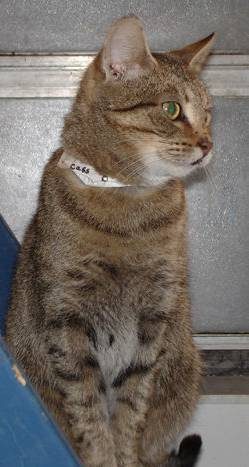

In [ ]:
from PIL import Image
# из класса image мы сохранили эту картинку
img = Image.open("/content/cats_set/cat.4043.jpg")
print(f"Image format: {img.format}; shape: {img.size}; color scheme: {img.mode}")
img
# Размер картинки 249 на 467, RGB - цвета

Image format: JPEG; shape: (297, 447); color scheme: RGB


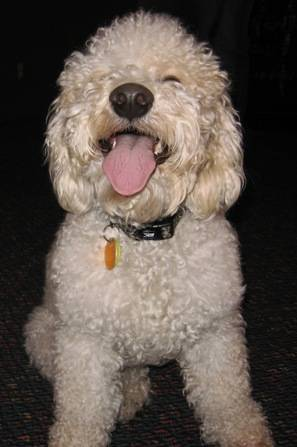

In [ ]:
img_1 = Image.open("/content/dogs_set/dog.4003.jpg")
print(f"Image format: {img_1.format}; shape: {img_1.size}; color scheme: {img_1.mode}")
img_1
# Размер картинки 297 на 447, RGB - цвета

In [222]:
df.shape
# 1000 изображений, 2 класса: кошки и собаки
# здесь уже поделено на лейблы

(1000, 2)

In [223]:
df.columns

Index(['image_path', 'label'], dtype='object')

In [224]:
df.label.unique()
# нужно лейблы закодировать в числа

array(['cats_set', 'dogs_set'], dtype=object)


**Подготовка данных для CNN**

In [ ]:
class ImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx]['image_path']
    label = self.dataframe.iloc[idx]['label']

    try:
      image = Image.open(img_path).convert('RGB')
    except Exception as e:
      print(f"Error loading image: {img_path}, error: {e}")
      return None
  # Преобразовала PIL изображения в тензоры перед тем, как использовать модуль v2
    image = transforms.ToTensor()(image)

    if self.transform:
      image = self.transform(image)
    # попыталась сконвертировать лейблы к числовое представление, 0 - для кошек, 1 - для собак
    # а также images
    label_int = 0 if label == 'cats_set' else 1
    return image, label_int

In [ ]:
# трансформирую изображения, стандартизация
# воспользуюсь модулем v2
from torchvision.transforms import v2
transform = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True), # antialias=True - сглаживание при изменении размера изображения
    # я думала, что обрезка и изменение размера помогут мне создать вариации исходных изображений, что является одной из форм увеличения объема данных
    v2.RandomHorizontalFlip(p=0.5), # Горизонтальное переключение
    v2.ToDtype(torch.float32, scale=True), # scale=True - масштабируются от диапазона [0, 255] до диапазона [0, 1] путем деления на 255
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size = 0.2, random_state=42)

In [ ]:
train_dataset = ImageDataset(train_df, transform=transform)
test_dataset = ImageDataset(test_df, transform=transform)

In [ ]:
# создам DataLoader
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

In [ ]:
# Протестирую Dataloader, посмотрю на информацию
for images, labels in train_loader:
    print(f"Shape of batch images: {images.shape}")
    print(f"Shape of batch labels: {labels.shape}")
    print(f"Sample labels: {labels[:5]}") # первые 5
    break

Shape of batch images: torch.Size([64, 3, 224, 224])
Shape of batch labels: torch.Size([64])
Sample labels: tensor([0, 1, 0, 1, 0])



# **Сверточные слои**

In [ ]:
class ConvNetMNIST(nn.Module):
    def __init__(self):
        super().__init__()
#         # in_channels=3, т.к цвет RGB, ядро = 3, padding = same - это  выходные данные сверточного слоя будут иметь те же пространственные размеры (высоту и ширину), что и входные данные, путем добавления границы из нулей вокруг входных данных
        self.conv_1 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding='same')
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2) # уменьшает  размеры в 2 раза

        self.conv_2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=3, padding='same')
        self.flatten = nn.Flatten()
# 56 - это приблизительное значение выходного размера после двух преобразований и двух объединений слоев с заполнением и размером ядра = 3
        self.fc_1 = nn.Linear(20 * 56 * 56, 128)
        self.fc_2 = nn.Linear(128, 2)

    def forward(self, x):
        pred = self.conv_1(x)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.conv_2(pred)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.flatten(pred)
        pred = self.fc_1(pred)
        pred = self.relu(pred)
        pred = self.fc_2(pred)
        return pred


# **Обучение модели**


# **Попытка №1**

In [ ]:
model1 = ConvNetMNIST()
optimizer = optim.AdamW(model1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = ConvNetMNIST().to(device)

In [ ]:
num_epochs = 10
# Это train
for epoch in range(num_epochs):
    model1.train()
    running_loss = 0.0
    running_corrects = 0

    # добавлю tqdm для отслеживания прогресса
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model1(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        progress_bar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Epoch 1/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.6922 Acc: 0.5162


Epoch 2/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 0.6931 Acc: 0.5025


Epoch 3/10:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 0.6941 Acc: 0.4775


Epoch 9/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.6918 Acc: 0.5312


Epoch 10/10:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.6920 Acc: 0.5288



# **Оценка**

In [ ]:
# оценка на тесте
from sklearn.metrics import classification_report, confusion_matrix
model1.eval()
running_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    # также добавлю tqdm для отслеживания прогресса
    progress_bar = tqdm(val_loader, desc='Testing')
    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model1(inputs)
        _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = running_corrects.double() / len(test_dataset)
print(f'Test Accuracy: {test_acc:.4f}')
print("Classification Report for CNN:")
print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))

Testing:   0%|          | 0/4 [00:00<?, ?it/s]

Test Accuracy: 0.4900
Classification Report for CNN:
              precision    recall  f1-score   support

         Cat       0.48      0.78      0.60        96
         Dog       0.52      0.22      0.31       104

    accuracy                           0.49       200
   macro avg       0.50      0.50      0.45       200
weighted avg       0.50      0.49      0.45       200



Test Accuracy: 0.4900

Достаточно мало, попробую поэкспериментировать еще.

Добавлю нормализацию батча и dropout


# **Попытка №2**

In [ ]:
torch.manual_seed(42)
#torch.cuda.manual_seed(42)

In [ ]:
class ImageDataset2(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx]['image_path']
    label = self.dataframe.iloc[idx]['label']

    try:
      image = Image.open(img_path).convert('RGB')
    except Exception as e:
      print(f"Error loading image: {img_path}, error: {e}")
      return None
  # Преобразовала PIL изображения в тензоры перед тем, как использовать модуль v2
    image = transforms.ToTensor()(image)

    if self.transform:
      image = self.transform(image)
    # попыталась сконвертировать лейблы к числовое представление, 0 - для кошек, 1 - для собак
    # а также images
    label_int = 0 if label == 'cats_set' else 1
    return image, label_int

In [ ]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size = 0.2, random_state=42)

In [ ]:
train_dataset = ImageDataset2(train_df, transform=transform)
test_dataset = ImageDataset2(test_df, transform=transform)

In [ ]:
# создам DataLoader
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [ ]:
# трансформирую изображения, стандартизация
# воспользуюсь модулем v2
from torchvision.transforms import v2
transform = v2.Compose([
    v2.RandomResizedCrop(size=(224, 224), antialias=True), # antialias=True - сглаживание при изменении размера изображения
    # я думала, что обрезка и изменение размера помогут мне создать вариации исходных изображений, что является одной из форм увеличения объема данных
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
class ConvNetMNIST12(nn.Module):
    def __init__(self):
        super().__init__()
        # 1 слой
        self.conv_1 = nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3, padding='same')
        self.bn1 = nn.BatchNorm2d(10)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)

        # 2 слой
        self.conv_2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=3, padding='same')
        self.bn2 = nn.BatchNorm2d(20)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout2 = nn.Dropout(0.2)
        self.flatten = nn.Flatten()

        self.fc_1 = nn.Linear(20 * 56 * 56, 128)
        self.dropout3 = nn.Dropout(0.2)
        self.fc_2 = nn.Linear(128, 2)

    def forward(self, x):
        pred = self.conv_1(x)
        pred = self.bn1(pred)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.dropout1(pred)
        pred = self.conv_2(pred)
        pred = self.bn2(pred)
        pred = self.relu(pred)
        pred = self.pool(pred)
        pred = self.dropout2(pred)
        pred = self.flatten(pred)
        pred = self.fc_1(pred)
        pred = self.relu(pred)
        pred = self.dropout3(pred)
        pred = self.fc_2(pred)
        return pred

In [ ]:
model2 = ConvNetMNIST12()
optimizer = optim.Adam(model2.parameters(), lr=0.001) # попробовала просто Adam
criterion = nn.CrossEntropyLoss()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2 = ConvNetMNIST12().to(device)

In [ ]:
num_epochs = 10
# Это train
for epoch in range(num_epochs):
    model2.train()
    running_loss = 0.0
    running_corrects = 0

    # добавлю tqdm для отслеживания прогресса
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model2(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        progress_bar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Epoch 1/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 0.7114 Acc: 0.4875


Epoch 2/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 0.7047 Acc: 0.5062


Epoch 3/10:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 8/10 - Loss: 0.6971 Acc: 0.5175


Epoch 9/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 0.7099 Acc: 0.4900


Epoch 10/10:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 0.6931 Acc: 0.5162


In [ ]:
# оценка на тесте
from sklearn.metrics import classification_report, confusion_matrix
model2.eval()
running_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    # также добавлю tqdm для отслеживания прогресса
    progress_bar = tqdm(val_loader, desc='Testing')
    for inputs, labels in progress_bar:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model2(inputs)
        _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = running_corrects.double() / len(test_dataset)
print(f'Test Accuracy: {test_acc:.4f}')
print("Classification Report for CNN:")
print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))

Testing:   0%|          | 0/7 [00:00<?, ?it/s]

Test Accuracy: 0.5050
Classification Report for CNN:
              precision    recall  f1-score   support

         Cat       0.47      0.29      0.36        96
         Dog       0.52      0.70      0.60       104

    accuracy                           0.51       200
   macro avg       0.50      0.50      0.48       200
weighted avg       0.50      0.51      0.48       200



Test Accuracy: 0.5050

Epoch 10/10:

Loss: 0.6931 Acc: 0.5162

Тоже мало, предсказывает половину


# **Попытка №3**

Все заново, попробую загрузить датасет через cv2, не знаю, почему я думала, что d scv его нужно выгружать.

In [360]:
import json
import os
# Замените на свои значения
token = {"username":"ksyushasemina","key":"ce4280ac01c4fa1f5dd6bac35cda82de"}

with open('/content/kaggle.json', 'w') as file:
    json.dump(token, file)
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v /content
!kaggle datasets download -d aleemaparakatta/cats-and-dogs-mini-dataset
!cd datasets/aleemaparakatta/cats-and-dogs-mini-dataset/
!pwd
!unzip datasets/aleemaparakatta/cats-and-dogs-mini-dataset/cats-and-dogs-mini-dataset.zip

- path is now set to: /content
Dataset URL: https://www.kaggle.com/datasets/aleemaparakatta/cats-and-dogs-mini-dataset
License(s): unknown
cats-and-dogs-mini-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
/content
Archive:  datasets/aleemaparakatta/cats-and-dogs-mini-dataset/cats-and-dogs-mini-dataset.zip
replace cats_set/cat.4001.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: cats_set/cat.4001.jpg   
  inflating: cats_set/cat.4002.jpg   
  inflating: cats_set/cat.4003.jpg   
  inflating: cats_set/cat.4004.jpg   
  inflating: cats_set/cat.4005.jpg   
  inflating: cats_set/cat.4006.jpg   
  inflating: cats_set/cat.4007.jpg   
  inflating: cats_set/cat.4008.jpg   
  inflating: cats_set/cat.4009.jpg   
  inflating: cats_set/cat.4010.jpg   
  inflating: cats_set/cat.4011.jpg   
  inflating: cats_set/cat.4012.jpg   
  inflating: cats_set/cat.4013.jpg   
  inflating: cats_set/cat.4014.jpg   
  inflating: cats_set/cat.4015.jpg   
  in

In [361]:
# Разделю заранее на два списка
images = []
labels = []

# Сразу же поставлю размер изображение 256, чтобы не было проблем в дальнейшем
IMG_SIZE = 256

# Сначала я обработаю кошек
cats_dir = os.path.join(data_dir, 'cats_set')
for image_path in os.listdir(cats_dir):
    image = cv2.imread(os.path.join(cats_dir, image_path))
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE)) # и размер тоже поменяю
    images.append(image)
    labels.append(0)  # здесь метка для кошек

# Потом обработаю собак
dogs_dir = os.path.join(data_dir, 'dogs_set')
for image_path in os.listdir(dogs_dir):
    image = cv2.imread(os.path.join(dogs_dir, image_path))
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))  # тоже поменяю размер на 256
    images.append(image)
    labels.append(1)  # метка для собак

In [403]:
print(f'Загружено {len(images)} изображений.')

Загружено 1000 изображений.


In [404]:
# Преобразую в массивы Numpy
images = np.array(images)
labels = np.array(labels)

In [405]:
torch.manual_seed(43)

In [406]:
# Нормализация пикселей, самый простой способ - поделить на 255.0
images_normal = images / 255.0  # Здесь нормализуется [0, 1]

In [407]:
print(labels.shape)
print(images.shape)
# посмотрю размер массива

(1000,)
(1000, 256, 256, 3)


• N — количество изображений (размер батча),

   • H — высота изображения,

   • W — ширина изображения,

   • C — количество каналов (3 для RGB).

In [408]:
images_normal = images_normal.transpose((0, 3, 1, 2))

In [ ]:
print(images_normal.shape)
# массив с размером (1000, 256, 256, 3)

In [409]:
# Преобразую картинки и лейбы в тензоры
images_tensor = torch.from_numpy(images_normal).float()
labels_tensor = torch.from_numpy(labels).long()

In [410]:
X_train, X_test, y_train, y_test = train_test_split(images_tensor, labels_tensor, test_size=0.2, random_state=42)

In [411]:
class ImageDataset4(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
    image = self.images[idx]
    label = self.labels[idx]
# изображение в PIL-изображение для transform
    if self.transform:
      image = transforms.ToPILImage()(image)
      image = self.transform(image)
    else:
      image = image

    return image, label

In [412]:
# Аугментация даты, так как маленький датасет
train_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # нормализую все к 0.5
])

test_transform = transforms.Compose([
    transforms.Resize(128),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # нормализую все к 0.5
])

In [414]:
train_dataset = ImageDataset4(X_train, y_train, transform=train_transform)
test_dataset = ImageDataset4(X_test, y_test, transform=test_transform)

In [415]:
# Создам даталоадер
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [416]:
class Conv12345(nn.Module):
    def __init__(self):
        super(Conv12345, self).__init__()

        # 1 слой
        self.conv_1 = nn.Conv2d(in_channels=3, out_channels=20, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(20)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)

        # 2 слой
        self.conv_2 = nn.Conv2d(in_channels=20, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.dropout2 = nn.Dropout(0.2)

        self.flatten = nn.Flatten()

        self.fc_1 = nn.Linear(32 * 56 * 56, 128)
        self.dropout3 = nn.Dropout(0.2)
        self.fc_2 = nn.Linear(128, 2)

    def forward(self, x):
        # 1 слой
        x = self.conv_1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        # 2 слой
        x = self.conv_2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout2(x)

        x = self.flatten(x)
        x = self.fc_1(x)
        x = self.dropout3(x)
        x = self.fc_2(x)
        return x

In [417]:
model4 = Conv12345()
optimizer = optim.SGD(model4.parameters(), lr=0.002, momentum=0.9)
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model4 = Conv12345().to(device)

In [418]:
from tqdm import tqdm
num_epochs = 20

for epoch in range(num_epochs):
    model4.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', unit='batch'):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model4(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Epoch 1/20: 100%|██████████| 13/13 [01:05<00:00,  5.01s/batch]


Epoch 1/20 - Loss: 0.7117 Acc: 0.5312


Epoch 2/20: 100%|██████████| 13/13 [01:12<00:00,  5.59s/batch]


Epoch 2/20 - Loss: 0.7086 Acc: 0.5312


Epoch 3/20: 100%|██████████| 13/13 [01:08<00:00,  5.25s/batch]


...

Epoch 18/20 - Loss: 0.7146 Acc: 0.5425


Epoch 19/20: 100%|██████████| 13/13 [01:08<00:00,  5.26s/batch]


Epoch 19/20 - Loss: 0.7145 Acc: 0.5450


Epoch 20/20: 100%|██████████| 13/13 [01:08<00:00,  5.28s/batch]

Epoch 20/20 - Loss: 0.7131 Acc: 0.5275


In [419]:
# Оценка модели
model4.eval()
running_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc='Testing', unit='batch'):
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model4(inputs)
        _, preds = torch.max(outputs, 1)

        running_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = running_corrects.double() / len(test_dataset)
print(f'Test Accuracy: {test_acc:.4f}')

Testing: 100%|██████████| 4/4 [00:08<00:00,  2.06s/batch]

Test Accuracy: 0.4950


Test Accuracy: 0.4950

Epoch 20/20 - Loss: 0.7131 Acc: 0.5275

Все, я сдаюсь.
Добавила дата аугментацию


Пробовала другой оптимизатор, Accuracy все равно в пределах 0.5

Наверное, я где-то ошиблась.